1. Include the data set and preprocessing for following machine learning.

In [46]:
## import libs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
# from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

##include minist dataset
mnist = fetch_openml('mnist_784', version=1)
print(mnist.keys())
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

##Preprocessing
#alignment
X = X.to_numpy()
X = X.astype(np.float32)
y = y.astype(np.int64)
y = y.to_numpy()
#normalization
X = X / 255.0
# print(X[0])
# print(y[0])

##Split the data set into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=0)

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(70000, 784)
(70000,)


2. Classifier Models Set up

In [47]:
## Minimum Euclidean Distance Classifier
class MED:
    def __init__(self):
        pass

    def fit(self, X, y):
        self.means = []
        self.classes = np.unique(y)
        for w in self.classes:
            X_w = X[y == w]
            mean_w = np.mean(X_w, axis=0)
            self.means.append(mean_w)
        self.means = np.array(self.means)

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.means, axis=2)
        return self.classes[np.argmin(distances, axis=1)]
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
## Mnimun Mahalanobis Distance Classifier
class MMD:
    def __init__(self):
        pass

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.covariance = np.cov(X, rowvar=False) + 1e-6 * np.eye(X.shape[1])  
        self.inv_covariance = np.linalg.inv(self.covariance)
        self.means = []
        for w in self.classes:
            X_w = X[y == w]
            mean_w = np.mean(X_w, axis=0)
            self.means.append(mean_w)
        self.means = np.array(self.means)

    def predict(self, X):
        diff = X[:, np.newaxis] - self.means
        distances = np.einsum('ijk,kl,ijl->ij', diff, self.inv_covariance, diff)
        return self.classes[np.argmin(distances, axis=1)]
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
## Bayes Classifier
class Bayes:
    def __init__(self):
        pass

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = []
        self.means = []
        self.covariances = []
        for w in self.classes:
            X_w = X[y == w]
            prior_w = X_w.shape[0] / X.shape[0]
            mean_w = np.mean(X_w, axis=0)
            cov_w = np.cov(X_w, rowvar=False) + 1e-6 * np.eye(X.shape[1])  
            self.priors.append(prior_w)
            self.means.append(mean_w)
            self.covariances.append(cov_w)
        self.priors = np.array(self.priors)
        self.means = np.array(self.means)
        self.covariances = np.array(self.covariances)

    def predict(self, X):
        log_likelihoods = []
        for w in range(len(self.classes)):
            mean_w = self.means[w] 
            cov_w = self.covariances[w]
            inv_cov_w = np.linalg.inv(cov_w)
            det_cov_w = np.linalg.det(cov_w)
            diff = X - mean_w
            log_likelihood_w = -0.5 * np.sum(diff @ inv_cov_w * diff, axis=1) - 0.5 * np.log(det_cov_w) + np.log(self.priors[w])
            log_likelihoods.append(log_likelihood_w)
        log_likelihoods = np.array(log_likelihoods).T
        return self.classes[np.argmax(log_likelihoods, axis=1)]
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
## Linear Regression Classifier





3. Evaluate Classification

In [48]:
classifier_med=MED()
classifier_med.fit(X_train, y_train)
y_pred_med=classifier_med.predict(X_test)   
accuracy_med=classifier_med.score(X_test,y_test)
print("MED accuracy:", accuracy_med)

# classifier_bayes=Bayes()
# classifier_bayes.fit(X_train, y_train)
# y_pred_bayes=classifier_bayes.predict(X_test)
# accuracy_bayes=classifier_bayes.score(X_test,y_test)
# print("Bayes accuracy:", accuracy_bayes)

classifier_mmd=MMD()
classifier_mmd.fit(X_train, y_train)
y_pred_mmd=classifier_mmd.predict(X_test)
accuracy_mmd=classifier_mmd.score(X_test,y_test)
print("MMD accuracy:", accuracy_mmd)

classifier_lr=LogisticRegression(max_iter=1000)
classifier_lr.fit(X_train, y_train)
y_pred_lr=classifier_lr.predict(X_test)
accuracy_lr=classifier_lr.score(X_test,y_test)
print("Logistic Regression accuracy:", accuracy_lr)

MED accuracy: 0.805
MMD accuracy: 0.8488
Logistic Regression accuracy: 0.9191


4. Dimension Reduction

In [49]:
## PCA for Dimension Reduction
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        covariance_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components = eigenvectors[:, sorted_indices[:self.n_components]]

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)




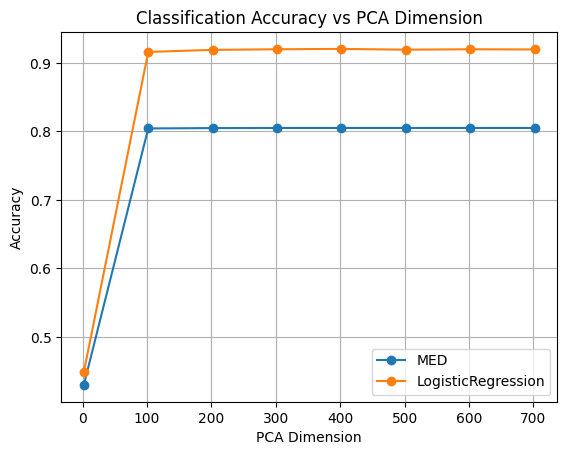

In [50]:
def visualize(dimensions,models,X_train,X_test,y_train,y_test):
    accuracys=[]
    for n_components in dimensions:
        pca = PCA(n_components=n_components)
        pca.fit(X_train)
        X_train_pca = pca.transform(X_train)
        X_test_pca = pca.transform(X_test)
        model_accuracys=[]
        for model in models:
            model.fit(X_train_pca, y_train)
            accuracy = model.score(X_test_pca, y_test)
            model_accuracys.append(accuracy)
        accuracys.append(model_accuracys)
    return accuracys

dimensions = np.arange(2, 785, 100)
models = [MED(),LogisticRegression(max_iter=1000)]
accuracys = visualize(dimensions,models,X_train,X_test,y_train,y_test)

for j, model in enumerate(models):
    acc_list = [acc[j] for acc in accuracys]
    plt.plot(dimensions, acc_list, marker='o', label=type(model).__name__)

plt.xlabel('PCA Dimension')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy vs PCA Dimension')
plt.legend()
plt.grid(True)
plt.show()